# VLM Prompt Optimizer
Multi-agent loop that finds the optimal prompt for object identification.

**Student** (VLM) describes the object inside a red bounding box → **Judge** checks correctness against GT annotation metadata → **Teacher** (VLM) refines the prompt. Repeats until all batch instances are correct or `MAX_ITERATIONS` is reached.

| Section | Description |
|---------|-------------|
| 0. Imports & Config | Libraries, env loading, constants |
| 1. Helper Functions | Data loading, bbox drawing, VLM wrappers, judge logic, metrics |
| 2. Initialize | API client, instance pool, hyperparameters & initial prompt |
| 3. Optimization Loop | Single executable cell — run to start training |
| 4. Results | Accuracy table, performance plots, best prompt |

## 0. Imports & Config

In [15]:
import os, re, json, base64, random, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image, ImageDraw, ImageFont
from pycocotools import mask as mask_util
from ollama import Client

# -- Resolve repo root --------------------------------------------------------
_cwd = os.getcwd()
for _candidate in [_cwd, os.path.dirname(_cwd)]:
    if os.path.isdir(os.path.join(_candidate, 'sam3')):
        REPO_ROOT = _candidate
        break
else:
    REPO_ROOT = _cwd

# -- Load OLLAMA_API_KEY from env.env -----------------------------------------
_env_path = os.path.join(REPO_ROOT, 'env.env')
if os.path.isfile(_env_path):
    with open(_env_path) as _f:
        for _line in _f:
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ[_k.strip()] = _v.strip().strip('"').strip("'")

OLLAMA_API_KEY = os.environ.get('OLLAMA_API_KEY', '')
VLM_MODEL      = 'qwen3-vl:235b-cloud'

_key_status = 'set' if OLLAMA_API_KEY else 'MISSING -- add OLLAMA_API_KEY to env.env'
print(f'REPO_ROOT : {REPO_ROOT}')
print(f'API key   : {_key_status}')
print(f'VLM model : {VLM_MODEL}')

REPO_ROOT : /Users/marcolomele/Documents/Repos/sam3
API key   : set
VLM model : qwen3-vl:235b-cloud


In [16]:
# =============================================================================
# PAPERMILL PARAMETERS -- edit here or override via: papermill -p KEY VALUE
# =============================================================================
HUMAN_IN_LOOP           = True   # False for unattended GPU runs (papermill)
MAX_ITERATIONS          = 10
BATCH_SIZE              = 5
RANDOM_SEED             = 12
HELD_OUT_SIZE           = 0     # instances held out for unbiased evaluation
LOCAL_SEARCH_CANDIDATES = 3      # candidate instructions generated per teacher round
LOCAL_SEARCH_EVAL_SIZE  = 3     # instances used to score each candidate
DATA_DIR_OVERRIDE       = ''     # absolute path override; leave empty to use data/dev

# Directory where per-iteration failure grids are saved as JPEG for human review.
# Useful when running via shell/papermill where plt.show() is a no-op.
HITL_SAVE_DIR = os.path.join(REPO_ROOT, 'examples', 'hitl_feedback')

# -- Per-agent Ollama options -------------------------------------------------
# Student: deterministic (temp=0 + seed) for fair local-search comparison.
#   num_predict=256 gives headroom for the JSON object (~50 tokens actual).
#   repeat_penalty=1.1 reduces repetition in multi-field descriptions.
STUDENT_OPTIONS = {
    'temperature'   : 0.0,
    'seed'          : RANDOM_SEED,
    'num_predict'   : 256,
    'repeat_penalty': 1.1,
}

# Judge: also deterministic -- identical input must yield identical verdict.
#   num_predict=64 is generous for {"match": true, "reason": "..."}.
JUDGE_OPTIONS = {
    'temperature': 0.0,
    'seed'       : RANDOM_SEED,
    'num_predict': 64,
}

# Teacher: stochastic so local-search candidates diverge from each other.
#   temperature is also forced to 0.7 inside the loop (explicit safety net).
#   num_predict=512 handles 3-5 sentence instructions with room to spare.
#   num_ctx=8192 absorbs 10 iterations of history + failure transcripts.
TEACHER_OPTIONS = {
    'temperature': 0.7,
    'num_predict': 512,
    'num_ctx'    : 8192,
}

## 1. Helper Functions

### 1.1 Data loading & instance building

In [17]:
_ann_cache = {}

def _load_annotation(data_dir, take_uid):
    """Load and cache annotation.json for a take."""
    key = f'{data_dir}/{take_uid}'
    if key not in _ann_cache:
        with open(os.path.join(data_dir, take_uid, 'annotation.json')) as f:
            _ann_cache[key] = json.load(f)
    return _ann_cache[key]


def build_instance_pool(data_dir, top_k=5):
    """
    Scan data_dir and return candidate instances for prompt optimization.

    Heuristic: for each (take, object, camera) group, rank all frames by GT
    mask area (number of True pixels in the binary mask) and keep only the
    top-k. Larger area -> object occupies more of the frame, less likely to
    be occluded or tiny.

    Deduplication key: instance_id = take|object|camera|frame.
    Same (object, frame) from a different camera is a distinct key and allowed.
    """
    pool = []
    for take_uid in sorted(os.listdir(data_dir)):
        ann_path = os.path.join(data_dir, take_uid, 'annotation.json')
        if not os.path.isfile(ann_path):
            continue
        ann = _load_annotation(data_dir, take_uid)
        for obj_name, cams in ann.get('masks', {}).items():
            obj_clean = re.sub(r'_\d+$', '', obj_name)
            for cam, frames in cams.items():
                # Rank frames by mask area (descending)
                ranked = []
                for frame_str, rle in frames.items():
                    img_path = os.path.join(data_dir, take_uid, cam, f'{frame_str}.jpg')
                    if not os.path.isfile(img_path):
                        continue
                    mask_area = int(mask_util.decode(rle).sum())
                    ranked.append((mask_area, frame_str))
                ranked.sort(reverse=True)
                # Keep top-k by mask area
                for mask_area, frame_str in ranked[:top_k]:
                    pool.append({
                        'take_uid'         : take_uid,
                        'object_name'      : obj_name,
                        'object_name_clean': obj_clean,
                        'camera'           : cam,
                        'frame_str'        : frame_str,
                        'mask_area'        : mask_area,
                        'instance_id'      : f'{take_uid}|{obj_name}|{cam}|{frame_str}',
                    })
    return pool


def load_frame_and_mask(inst, data_dir):
    """Return (img_path, rgb_np, mask_bool) for an instance dict."""
    img_path = os.path.join(data_dir, inst['take_uid'], inst['camera'],
                            f"{inst['frame_str']}.jpg")
    ann  = _load_annotation(data_dir, inst['take_uid'])
    rle  = ann['masks'][inst['object_name']][inst['camera']][inst['frame_str']]
    rgb  = np.array(Image.open(img_path).convert('RGB'))
    H, W = rgb.shape[:2]
    mask = mask_util.decode(rle).astype(bool)
    if mask.shape != (H, W):
        mask = np.array(
            Image.fromarray(mask.astype(np.uint8) * 255).resize((W, H), Image.NEAREST)
        ) > 127
    return img_path, rgb, mask


print('1.1 Data helpers defined.')


1.1 Data helpers defined.


### 1.2 Bounding box drawing

In [18]:
def create_bounding_box(img_path, mask_np, color=(255, 0, 0), scale=1.2):
    """Return PIL Image with a rotated minimum bounding box drawn over the GT mask."""
    img  = Image.open(img_path).convert('RGB')
    w, h = img.size
    if mask_np.shape[0] != h or mask_np.shape[1] != w:
        mask_np = cv2.resize(mask_np.astype(np.uint8), (w, h),
                             interpolation=cv2.INTER_NEAREST).astype(bool)
    mask_u8     = mask_np.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    all_pts   = np.vstack(contours)
    rect      = cv2.minAreaRect(all_pts)
    cx, cy    = rect[0]; rw, rh = rect[1]; angle = rect[2]
    rect_s    = ((cx, cy), (rw * scale, rh * scale), angle)
    diag      = np.hypot(rw * scale, rh * scale)
    img_diag  = np.hypot(w, h)
    thickness = max(1, min(4, int(round(diag / img_diag * 20))))
    box_pts   = cv2.boxPoints(rect_s).astype(np.intp)
    # Clip corners to image bounds: where the object touches the border the box
    # follows the image edge, keeping the polygon visually closed.
    box_pts   = np.clip(box_pts, [0, 0], [w - 1, h - 1])
    arr       = np.array(img)
    box_pts = np.clip(box_pts, [0, 0], [w - 1, h - 1])
    cv2.polylines(arr, [box_pts], isClosed=True, color=color, thickness=thickness)
    return Image.fromarray(arr)


def prepare_instance_image(inst, data_dir):
    """Load frame + GT mask, draw bounding box. Returns (bbox_np, img_path, rgb, mask)."""
    img_path, rgb, mask = load_frame_and_mask(inst, data_dir)
    bbox_pil = create_bounding_box(img_path, mask)
    return np.array(bbox_pil), img_path, rgb, mask


print('1.2 Bounding box helpers defined.')

1.2 Bounding box helpers defined.


### 1.3 VLM call wrappers

In [19]:
def vlm_call(client, model, image_np, prompt, options=None):
    """Send a numpy RGB image + prompt to Ollama, return streamed text."""
    _, buf  = cv2.imencode('.jpg', cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))
    img_b64 = base64.b64encode(buf).decode()
    msgs    = [{'role': 'user', 'content': prompt, 'images': [img_b64]}]
    opts    = options if options is not None else {'num_predict': 512}
    text    = ''
    for part in client.chat(model=model, messages=msgs, stream=True, options=opts):
        text += part.message.content or ''
    return text.strip()


def vlm_call_text(client, model, system_prompt, user_prompt, options=None):
    """Text-only VLM call (no image) with system and user messages."""
    msgs = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': user_prompt},
    ]
    opts = options if options is not None else {'num_predict': 64}
    text = ''
    for part in client.chat(model=model, messages=msgs, stream=True, options=opts):
        text += part.message.content or ''
    return text.strip()


print('1.3 VLM call wrappers defined.')


1.3 VLM call wrappers defined.


### 1.4 JSON parsing

In [20]:
def parse_json_fence(text):
    """Strip markdown ```json fencing if present and return the inner content."""
    lines = text.splitlines()
    for i, line in enumerate(lines):
        if line.strip() in ('```json', '```'):
            inner = '\n'.join(lines[i + 1:])
            text  = inner.split('```')[0]
            break
    return text.strip()


def parse_student_output(raw_text):
    """Parse Student VLM output into a dict, or return None on failure."""
    try:
        return json.loads(parse_json_fence(raw_text))
    except Exception:
        return None


print('1.4 JSON parsing helpers defined.')

1.4 JSON parsing helpers defined.


### 1.5 Judge logic (two-step)

In [21]:
_STOP_WORDS = {'a', 'an', 'the', 'of', 'and', 'or', 'in', 'on', 'at',
               'to', 'for', 'with', 'by', 'is', 'it', 'its'}

def _get_nouns(name):
    """Tokenize object name into content words (strip stop words and short tokens)."""
    return [tok for tok in name.lower().split()
            if tok not in _STOP_WORDS and len(tok) > 1]


_JUDGE_SYSTEM = '''You are a strict but fair evaluator. Decide if a student correctly identified an object.

Matching rules:
- CORRECT if the student names the object's primary category, even loosely.
  "sauce" matches "oyster sauce bottle". "bottle" also matches.
- INCORRECT if the student names a completely unrelated object.
  "cup" does NOT match "oyster sauce bottle".
- Ignore colour, size, and viewpoint descriptors -- evaluate the noun only.
- Semantic equivalence counts.

Return JSON only: {"match": true|false, "reason": "<one sentence>"}'''


def _judge_exact(object_name_clean, student_parsed):
    """
    Step 1: fast substring check with no VLM call.
    Returns a verdict dict if decidable, else None (escalate to Step 2).
    """
    if student_parsed is None:
        return {'match': False, 'method': 'exact',
                'reason': 'student output failed to parse as JSON'}
    student_obj = student_parsed.get('object', '').lower().strip()
    if not student_obj:
        return {'match': False, 'method': 'exact',
                'reason': 'student "object" field is empty'}
    for noun in _get_nouns(object_name_clean):
        if noun in student_obj:
            return {'match': True, 'method': 'exact',
                    'reason': f'noun "{noun}" found in student output "{student_obj}"'}
    return None  # inconclusive -- escalate to VLM judge


def _judge_vlm(client, model, object_name_clean, student_parsed, options=None):
    """Step 2: VLM semantic check. Only called when Step 1 is inconclusive."""
    student_obj = student_parsed.get('object', '') if student_parsed else ''
    user_msg    = f'Target object: {object_name_clean}\nStudent said: {student_obj}'
    raw         = vlm_call_text(client, model, _JUDGE_SYSTEM, user_msg, options=options)
    try:
        result = json.loads(parse_json_fence(raw))
        return {'match': bool(result.get('match', False)),
                'method': 'vlm',
                'reason': result.get('reason', raw[:120])}
    except Exception:
        return {'match': False, 'method': 'vlm',
                'reason': f'judge parse failed -- raw: {raw[:80]}'}


def judge_instance(client, model, inst, student_output, options=None):
    """
    Full two-step judge for one instance.
    Returns: {instance_id, match, method, reason}.
    """
    result = _judge_exact(inst['object_name_clean'], student_output['parsed'])
    if result is None:
        result = _judge_vlm(client, model, inst['object_name_clean'],
                            student_output['parsed'], options=options)
    return {'instance_id': inst['instance_id'], **result}


print('1.5 Judge logic defined.')


1.5 Judge logic defined.


### 1.6 Metrics computation

In [22]:
def compute_accuracy(verdicts):
    """Fraction of verdicts where match is True."""
    if not verdicts:
        return 0.0
    return sum(v['match'] for v in verdicts) / len(verdicts)


def get_iteration_verdicts(all_verdicts, iteration):
    """Filter all_verdicts to a single iteration."""
    return [v for v in all_verdicts if v.get('iteration') == iteration]


def stratified_sample(pool, n):
    """
    Sample n instances with stratification across object_name_clean categories.
    Guarantees at least one instance per unique object category (up to n objects).
    Remaining slots are filled uniformly from the full pool.
    """
    if n >= len(pool):
        return list(pool)
    by_object = {}
    for inst in pool:
        by_object.setdefault(inst['object_name_clean'], []).append(inst)
    # One random draw per category (shuffled category order)
    obj_keys   = list(by_object.keys())
    random.shuffle(obj_keys)
    stratified = [random.choice(by_object[k]) for k in obj_keys[:n]]
    if len(stratified) >= n:
        return random.sample(stratified, n)
    # Fill remaining slots from pool excluding already-picked
    picked_ids = {inst['instance_id'] for inst in stratified}
    remainder  = [inst for inst in pool if inst['instance_id'] not in picked_ids]
    n_fill     = min(n - len(stratified), len(remainder))
    if n_fill:
        stratified.extend(random.sample(remainder, n_fill))
    return stratified


print('1.6 Metrics & sampling helpers defined.')


1.6 Metrics & sampling helpers defined.


### 1.7 Human-in-loop & evaluation helpers

In [23]:
def show_failure_grid(batch, student_outputs, verdicts, data_dir, max_show=5):
    """
    Display failure cases as an inline matplotlib grid for human inspection.
    Each panel shows the bbox image, target label, student output, and judge reason.
    Only called when HUMAN_IN_LOOP=True.
    """
    failures = [
        (inst, so, v)
        for inst, so, v in zip(batch, student_outputs, verdicts)
        if not v['match']
    ][:max_show]
    if not failures:
        print('  No failures to display.')
        return
    n = len(failures)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (inst, so, v) in zip(axes, failures):
        image_np, _, _, _ = prepare_instance_image(inst, data_dir)
        ax.imshow(image_np)
        student_obj = so['parsed'].get('object', '?') if so['parsed'] else 'PARSE FAILED'
        ax.set_title(
            f"Target: {inst['object_name_clean']}\n"
            f"Said: \"{student_obj}\"\n"
            f"{v['reason'][:45]}",
            fontsize=7
        )
        ax.axis('off')
    plt.suptitle('Failure cases -- share a visual observation below', fontsize=10)
    plt.tight_layout()
    plt.show()


def save_failure_grid_to_disk(batch, student_outputs, verdicts, data_dir,
                               iteration, save_dir, max_show=5):
    """
    Save failure cases as a single annotated JPEG to save_dir/iter_{N:02d}_failures.jpg.

    Each panel is the bbox image with a dark header strip showing:
      • iteration number and failure index
      • target object label
      • what the student said
      • judge rejection reason (first 70 chars)

    Useful when plt.show() is a no-op (shell / papermill runs): the human can
    open the file in any image viewer, read the context, and then type their
    observation into the waiting input() prompt.

    Returns the saved path, or None if there were no failures.
    """
    failures = [
        (inst, so, v)
        for inst, so, v in zip(batch, student_outputs, verdicts)
        if not v['match']
    ][:max_show]
    if not failures:
        return None

    HEADER_H = 90   # px — tall enough for 3 lines of text at ~14px each
    GAP      = 4    # px between panels
    BG       = (30, 30, 30)
    HEADER_BG= (20, 20, 50)
    TITLE_C  = (255, 220, 60)   # yellow — iteration title
    TEXT_C   = (220, 220, 220)  # light grey — body text
    FAIL_C   = (255, 100, 100)  # red — judge reason

    # Try to load a small bitmap font; fall back to default if not available.
    try:
        _font_sm = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 13)
        _font_ti = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 13)
    except Exception:
        _font_sm = ImageFont.load_default()
        _font_ti = _font_sm

    panels = []
    for idx, (inst, so, v) in enumerate(failures):
        image_np, _, _, _ = prepare_instance_image(inst, data_dir)
        img = Image.fromarray(image_np)
        W, H = img.size

        student_obj = so['parsed'].get('object', '?') if so['parsed'] else 'PARSE FAILED'
        reason_short = v.get('reason', '')[:70]

        # Build header strip
        header = Image.new('RGB', (W, HEADER_H), color=HEADER_BG)
        draw = ImageDraw.Draw(header)
        draw.text((5, 4),  f"iter {iteration}  •  failure {idx + 1}/{len(failures)}", font=_font_ti, fill=TITLE_C)
        draw.text((5, 24), f"target : {inst['object_name_clean']}",                    font=_font_sm, fill=TEXT_C)
        draw.text((5, 42), f"said   : \"{student_obj}\"",                              font=_font_sm, fill=TEXT_C)
        draw.text((5, 62), f"reason : {reason_short}",                                 font=_font_sm, fill=FAIL_C)

        # Stack header above image
        panel = Image.new('RGB', (W, HEADER_H + H), color=BG)
        panel.paste(header, (0, 0))
        panel.paste(img, (0, HEADER_H))
        panels.append(panel)

    # Concatenate panels horizontally with a small gap
    total_w = sum(p.width for p in panels) + GAP * (len(panels) - 1)
    total_h = max(p.height for p in panels)
    composite = Image.new('RGB', (total_w, total_h), color=BG)
    x = 0
    for p in panels:
        composite.paste(p, (x, 0))
        x += p.width + GAP

    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f'iter_{iteration:02d}_failures.jpg')
    composite.save(path, quality=92)
    return path


def evaluate_on_subset(instances, prompt, client, model, data_dir,
                        student_options=None, judge_options=None):
    """
    Run student + judge on a fixed list of instances, return (accuracy, verdicts).
    Used for held-out evaluation each round and for local search candidate scoring.
    Does NOT update used_instance_ids or all_verdicts -- purely for measurement.
    """
    verdicts = []
    for inst in instances:
        image_np, _, _, _ = prepare_instance_image(inst, data_dir)
        raw    = vlm_call(client, model, image_np, prompt, options=student_options)
        parsed = parse_student_output(raw)
        so     = {'instance_id': inst['instance_id'], 'raw_text': raw, 'parsed': parsed}
        verdict = judge_instance(client, model, inst, so, options=judge_options)
        verdicts.append(verdict)
    return compute_accuracy(verdicts), verdicts


print('1.7 Human-in-loop & evaluation helpers defined.')

1.7 Human-in-loop & evaluation helpers defined.


### 1.7 Teacher

In [24]:
# -- Teacher prompt templates -------------------------------------------------
# The teacher ONLY revises the instruction text.
# SCHEMA_SUFFIX is pinned and appended automatically by build_student_prompt.
_TEACHER_SYSTEM = '''You are an expert prompt engineer improving a VLM prompt for object identification.
The VLM sees an image with a red rotated bounding box around an object and must describe it.

Your task: revise ONLY the instruction text. The JSON schema and output rules are fixed and
will be appended automatically -- do NOT include them in your response.

Constraints:
- Return ONLY the revised instruction text (1-5 sentences). Nothing else.
- Do not include any JSON schema, field definitions, or output rules.
- Do not include markdown formatting or code fences.
- The instruction must clearly ask the model to describe only the boxed object.
- If a human visual observation is provided, use it to address the specific visual difficulty. Treat human feedback as highly valuable signal.'''


def _clean_teacher_output(raw, fallback_instruction):
    """
    Clean teacher output: strip markdown fences, remove any schema fragments,
    fall back to current instruction if output is empty or malformed.
    """
    text = raw.strip()
    text = parse_json_fence(text).strip()
    for marker in ('Return exactly one valid JSON', '{\n  "colour"', 'Schema:', 'Rules:',
                   '"colour"', '"object"', '"view_independent'):
        if marker in text:
            text = text[:text.index(marker)].strip()
    if len(text) < 10:
        print(f'  [Teacher WARNING] Output too short ({len(text)} chars) -- keeping current instruction.')
        return fallback_instruction
    return text


def _build_teacher_msg(current_instruction, instruction_history, failures, human_obs=None):
    """Build the user message for the teacher VLM.
    human_obs: optional visual observation from the human this round.
    Rolling observations from previous rounds are included automatically.
    """
    history_lines = '\n'.join(
        f"  Iter {r['iteration']}  acc={r['cumulative_accuracy']:.1%}  "
        f"instruction={r['instruction'].replace(chr(10), ' ')[:80]}..."
        for r in instruction_history
    ) or '  (none yet)'

    # Rolling human observations from previous iterations
    past_obs = [
        f"  Iter {r['iteration']}: {r['human_obs']}"
        for r in instruction_history
        if r.get('human_obs')
    ]
    obs_history_section = (
        '\nPrevious human visual observations:\n' + '\n'.join(past_obs) + '\n'
        if past_obs else ''
    )

    # Current round human observation
    human_obs_section = (
        f'\nHuman visual observation of this batch\'s failures:\n  "{human_obs}"\n'
        if human_obs else ''
    )

    sample = random.sample(failures, min(5, len(failures)))
    failure_lines = '\n'.join(
        f"  [{i+1}] Target : {f['object_name_clean']}\n"
        f"       Student: {f['raw_text'][:200].strip()}\n"
        f"       Judge  : {f['reason']}"
        for i, f in enumerate(sample)
    )

    return (
        f'Instruction history (do not regress to lower-scoring versions):\n{history_lines}\n'
        f'{obs_history_section}'
        f'Current instruction:\n{current_instruction}\n'
        f'{human_obs_section}'
        f'Failure cases from this batch (up to 5):\n{failure_lines}\n\n'
        f'Return ONLY the revised instruction text (no schema, no JSON rules).'
    )


## 2. Initialize

### 2.1 API client

In [25]:
vlm_client = Client(
    host='https://ollama.com',
    headers={'Authorization': f'Bearer {OLLAMA_API_KEY}'}
)
print('VLM client ready.')

VLM client ready.


### 2.2 Load all instances from data_dir

In [26]:
# DATA_DIR is set from DATA_DIR_OVERRIDE (papermill param) or defaults to data/dev
DATA_DIR = DATA_DIR_OVERRIDE if DATA_DIR_OVERRIDE else os.path.join(REPO_ROOT, 'data/dev')

assert os.path.isdir(DATA_DIR), f'DATA_DIR not found: {DATA_DIR}'

print(f'Building instance pool from: {DATA_DIR}')
print('Ranking frames by mask area -- this takes a moment on large datasets...')
instance_pool = build_instance_pool(DATA_DIR)

print(f'\nDATA_DIR      : {DATA_DIR}')
print(f'Instance pool : {len(instance_pool)} instances  (top-5 frames by mask area per object-camera)')

take_counts = Counter(inst['take_uid'] for inst in instance_pool)
obj_counts  = Counter(inst['object_name_clean'] for inst in instance_pool)
print(f'\nTakes ({len(take_counts)}):')
for take, count in sorted(take_counts.items()):
    print(f'  {take[:50]:<50}  {count:>5} instances')
print(f'\nUnique objects ({len(obj_counts)}):')
for obj, count in sorted(obj_counts.items(), key=lambda x: -x[1]):
    print(f'  {obj:<40}  {count:>5} instances')


Building instance pool from: /Users/marcolomele/Documents/Repos/sam3/data/dev
Ranking frames by mask area -- this takes a moment on large datasets...

DATA_DIR      : /Users/marcolomele/Documents/Repos/sam3/data/dev
Instance pool : 434 instances  (top-5 frames by mask area per object-camera)

Takes (8):
  05e5f359-526d-4914-a86b-5a56cfcc0274                   30 instances
  0efd9fc1-0f49-403d-9252-93f119a3ea3c                  120 instances
  20bc64ed-0612-4f59-9822-7ef409c7fdd4                   10 instances
  7c187ae5-b793-42c2-abca-54e1d0822a32                   49 instances
  8acb2112-465c-4088-b502-65fd9704dd77                  150 instances
  901cebcb-d84b-43ed-a80f-719e62561b82                   10 instances
  ec6885cb-287c-421e-b16d-e63a59c21d80                   10 instances
  f3f87687-6c1d-415f-9fe0-5f0bdb031371                   55 instances

Unique objects (42):
  oyster sauce bottle                          20 instances
  white_bowl                                   20 ins

## 3. Optimization Loop

### 3.1 Hyperparameters & initial prompt

In [27]:
random.seed(RANDOM_SEED)

# -- Schema suffix (FIXED -- never modified by teacher) -----------------------
SCHEMA_SUFFIX = '''

Return exactly one valid JSON object and nothing else.

Schema:
{
  "colour": "<short color description>",
  "object": "<specific object name>",
  "view_independent_descriptors": "<view-independent descriptors>"
}

Rules:
- colour: only the boxed object's visible color(s)
- object: name the specific object
- view_independent_descriptors: only angle-independent descriptors (shape, texture, relations like on/under/held-by)
- Do not output markdown. Output JSON only.'''

# -- Initial instruction (only this part is revised by the teacher) -----------
INITIAL_INSTRUCTION = 'Describe only the object exactly inside the red box.'

def build_student_prompt(instruction):
    """Combine teacher-editable instruction with the fixed schema suffix."""
    return instruction.strip() + SCHEMA_SUFFIX

INITIAL_PROMPT = build_student_prompt(INITIAL_INSTRUCTION)

print(f'MAX_ITERATIONS          : {MAX_ITERATIONS}')
print(f'BATCH_SIZE              : {BATCH_SIZE}  (pool has {len(instance_pool)} instances)')
print(f'RANDOM_SEED             : {RANDOM_SEED}')
print(f'HELD_OUT_SIZE           : {HELD_OUT_SIZE}')
print(f'LOCAL_SEARCH_CANDIDATES : {LOCAL_SEARCH_CANDIDATES}')
print(f'LOCAL_SEARCH_EVAL_SIZE  : {LOCAL_SEARCH_EVAL_SIZE}')
print(f'HUMAN_IN_LOOP           : {HUMAN_IN_LOOP}')
print(f'\nInitial instruction : {INITIAL_INSTRUCTION}')
print(f'\nFull initial prompt :\n{"-" * 60}\n{INITIAL_PROMPT}\n{"-" * 60}')


# -- Held-out set: fixed once, never used for training ------------------------
held_out    = stratified_sample(instance_pool, min(HELD_OUT_SIZE, len(instance_pool)))
held_out_ids = {inst['instance_id'] for inst in held_out}
print(f'\nHeld-out set: {len(held_out)} instances across '
      f'{len({i["object_name_clean"] for i in held_out})} object categories.')

# -- State initialisation -----------------------------------------------------
current_instruction      = INITIAL_INSTRUCTION
all_verdicts             = []
instruction_history      = []
prompt_history           = instruction_history  # alias -- section 4 plots read prompt_history
best_instruction         = INITIAL_INSTRUCTION
best_prompt              = INITIAL_PROMPT
best_held_out_accuracy   = 0.0
human_obs_history        = []
# Exclude held-out from training dedup set from the start
used_instance_ids        = set(held_out_ids)


MAX_ITERATIONS          : 10
BATCH_SIZE              : 5  (pool has 434 instances)
RANDOM_SEED             : 12
HELD_OUT_SIZE           : 0
LOCAL_SEARCH_CANDIDATES : 3
LOCAL_SEARCH_EVAL_SIZE  : 3
HUMAN_IN_LOOP           : True

Initial instruction : Describe only the object exactly inside the red box.

Full initial prompt :
------------------------------------------------------------
Describe only the object exactly inside the red box.

Return exactly one valid JSON object and nothing else.

Schema:
{
  "colour": "<short color description>",
  "object": "<specific object name>",
  "view_independent_descriptors": "<view-independent descriptors>"
}

Rules:
- colour: only the boxed object's visible color(s)
- object: name the specific object
- view_independent_descriptors: only angle-independent descriptors (shape, texture, relations like on/under/held-by)
- Do not output markdown. Output JSON only.
------------------------------------------------------------

Held-out set: 0 instances ac

### 3.2 Run loop
Run this cell once to start training. State (`all_verdicts`, `prompt_history`, `best_prompt`) is written to module-level variables and consumed by Section 4.


  ITERATION 1 / 10
  Sampled 5 instances  (5 used so far, 429 remaining).

  [ Student ]
    [ 1] kitchen_paper                       -> milk carton
    [ 2] sterile swab with package           -> test strip
    [ 3] test device with package            -> card
    [ 4] black knife                         -> grater
    [ 5] Covid-19 Test Pack                  -> tissue box

  [ Judge ]
    [FAIL] kitchen_paper                       (vlm) The student identified a container (milk carton) which 
    [FAIL] sterile swab with package           (vlm) The student identified the object as a test strip, whic
    [FAIL] test device with package            (vlm) card is not the primary category of a test device with 
    [FAIL] black knife                         (vlm) The student identified the object as a grater, which is
    [FAIL] Covid-19 Test Pack                  (vlm) A tissue box is a completely unrelated object to a Covi

  Batch accuracy      : 0.0%  (0/5)
  Cumulative accuracy : 0.0% 

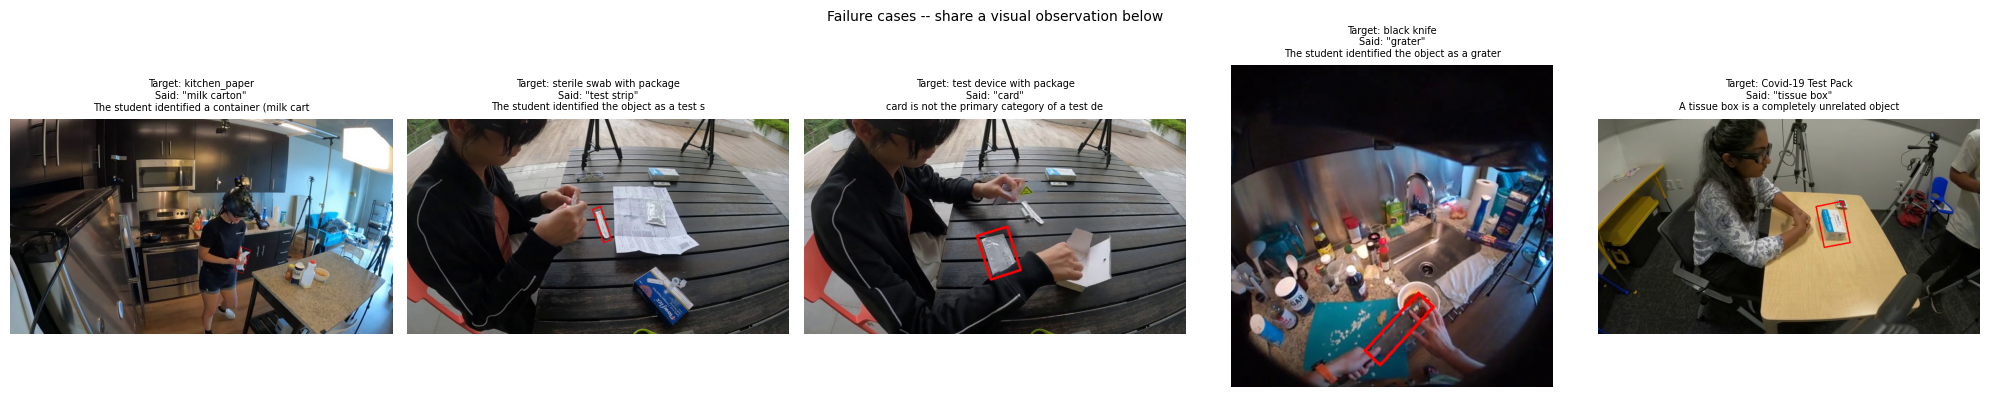

  Recorded observation: be more general; describe the largest object inside the red box
  Generating 3 candidate instructions...
    Candidate 1: acc=33.3%  Describe the largest object within the red rotated bounding box as the
    Candidate 2: acc=66.7%  Describe the largest object within the red bounding box using a genera
    Candidate 3: acc=33.3%  Describe the largest object inside the red bounding box using general 
  Selected candidate (acc=66.7%): Describe the largest object within the red bounding box using a general category

  ITERATION 2 / 10
  Sampled 5 instances  (10 used so far, 424 remaining).

  [ Student ]
    [ 1] oyster sauce bottle                 -> bottle
    [ 2] noodles                             -> frying pan
    [ 3] cooked noodles                      -> bowl
    [ 4] nonstick_pan                        -> frying pan
    [ 5] Covid-19 Test Pack                  -> box

  [ Judge ]
    [OK]   oyster sauce bottle                 (exact) noun "bottle" found in

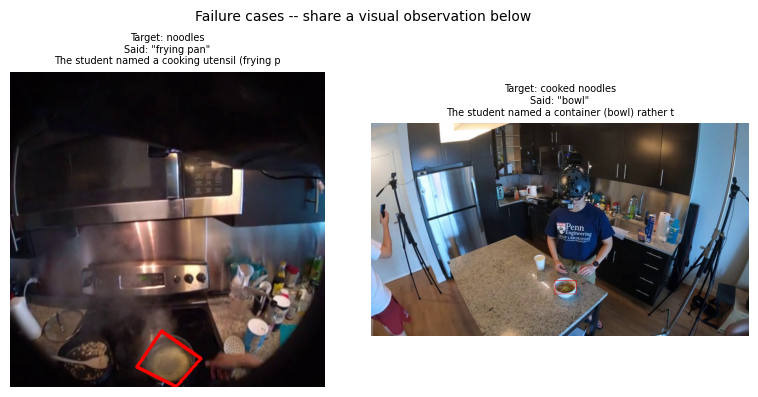

  Recorded observation: all: object to segment is inside container, red box overlaps container, so VLM should focus strictly on what's inside the red bounding box
  Generating 3 candidate instructions...
    Candidate 1: acc=66.7%  Focus strictly on the contents inside the red bounding box rather than
    Candidate 2: acc=66.7%  Focus strictly on the main object inside the red bounding box, ignorin
    Candidate 3: acc=66.7%  Focus strictly on the main subject within the red bounding box, not th
  Selected candidate (acc=66.7%): Focus strictly on the contents inside the red bounding box rather than any conta

  ITERATION 3 / 10
  Sampled 5 instances  (15 used so far, 419 remaining).

  [ Student ]
    [ 1] white bowl                          -> bowl
    [ 2] blue_chopping_board                 -> cutting board
    [ 3] black table                         -> hair
    [ 4] paper napkin                        -> sponge
    [ 5] oil bottle                          -> salad dressing bottle


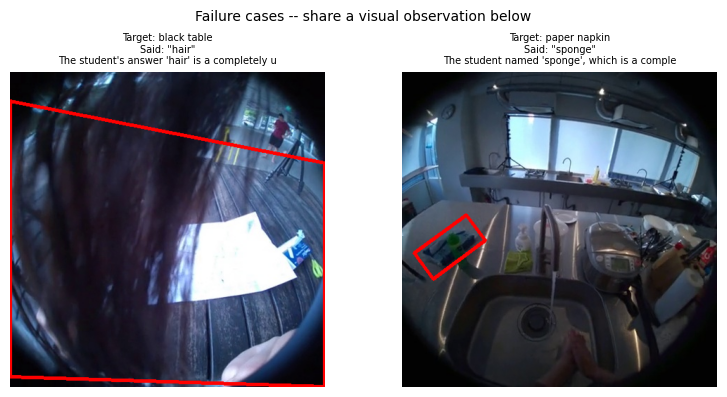

  Recorded observation: [1] heavely occluded ; [2] partially occluded by bottle and low light visibility, describe more generally
  Generating 3 candidate instructions...
    Candidate 1: acc=0.0%  Describe only the primary object inside the red bounding box using a s


KeyboardInterrupt: 

In [28]:
# -- Main loop ----------------------------------------------------------------
for iteration in range(1, MAX_ITERATIONS + 1):
    sep = '=' * 68
    print(f'\n{sep}')
    print(f'  ITERATION {iteration} / {MAX_ITERATIONS}')
    print(sep)

    # 1. Sample batch -- stratified, exclude already-used (camera, object, frame) combos
    available = [inst for inst in instance_pool
                 if inst['instance_id'] not in used_instance_ids]
    if len(available) < BATCH_SIZE:
        print(f'  [INFO] Only {len(available)} unused instances left -- resetting dedup set '
              f'(held-out preserved).')
        used_instance_ids.clear()
        used_instance_ids.update(held_out_ids)
        available = [inst for inst in instance_pool
                     if inst['instance_id'] not in used_instance_ids]
    batch = stratified_sample(available, min(BATCH_SIZE, len(available)))
    for inst in batch:
        used_instance_ids.add(inst['instance_id'])
    print(f'  Sampled {len(batch)} instances  ({len(used_instance_ids)} used so far, '
          f'{len(instance_pool) - len(used_instance_ids)} remaining).')

    # 2. Student
    student_prompt = build_student_prompt(current_instruction)
    print('\n  [ Student ]')
    student_outputs = []
    for idx, inst in enumerate(batch):
        image_np, _, _, _ = prepare_instance_image(inst, DATA_DIR)
        raw    = vlm_call(vlm_client, VLM_MODEL, image_np, student_prompt,
                          options=STUDENT_OPTIONS)
        parsed = parse_student_output(raw)
        student_outputs.append({'instance_id': inst['instance_id'],
                                 'raw_text': raw, 'parsed': parsed})
        obj_out = parsed.get('object', 'PARSE FAILED') if parsed else 'PARSE FAILED'
        print(f'    [{idx+1:>2}] {inst["object_name_clean"]:<35} -> {obj_out}')

    # 3. Judge
    print('\n  [ Judge ]')
    batch_verdicts = []
    for inst, so in zip(batch, student_outputs):
        verdict = judge_instance(vlm_client, VLM_MODEL, inst, so,
                                 options=JUDGE_OPTIONS)
        verdict['iteration'] = iteration
        batch_verdicts.append(verdict)
        all_verdicts.append(verdict)
        sym = '[OK]  ' if verdict['match'] else '[FAIL]'
        print(f'    {sym} {inst["object_name_clean"]:<35} ({verdict["method"]}) {verdict["reason"][:55]}')

    # 4. Compute metrics
    batch_acc = compute_accuracy(batch_verdicts)
    cumul_acc = compute_accuracy(all_verdicts)
    n_ok      = sum(v['match'] for v in batch_verdicts)
    n_ok_all  = sum(v['match'] for v in all_verdicts)
    print(f'\n  Batch accuracy      : {batch_acc:.1%}  ({n_ok}/{len(batch_verdicts)})')
    print(f'  Cumulative accuracy : {cumul_acc:.1%}  ({n_ok_all}/{len(all_verdicts)})')

    # 5. Held-out evaluation
    print('\n  [ Held-out evaluation ]')
    held_acc, _ = evaluate_on_subset(held_out, student_prompt, vlm_client, VLM_MODEL,
                                     DATA_DIR,
                                     student_options=STUDENT_OPTIONS,
                                     judge_options=JUDGE_OPTIONS)
    print(f'  Held-out accuracy   : {held_acc:.1%}')

    # 6. Record
    record = {
        'iteration'           : iteration,
        'instruction'         : current_instruction,
        'prompt'              : student_prompt,
        'batch_accuracy'      : batch_acc,
        'cumulative_accuracy' : cumul_acc,
        'held_out_accuracy'   : held_acc,
    }
    instruction_history.append(record)
    prompt_history = instruction_history  # alias for results cells

    # 7. Update best (tracked on held-out)
    if held_acc > best_held_out_accuracy:
        best_held_out_accuracy = held_acc
        best_instruction       = current_instruction
        best_prompt            = student_prompt
        print(f'  [BEST] New best prompt at iteration {iteration} '
              f'(held-out acc: {held_acc:.1%})')

    # 8. Early stop
    if batch_acc == 1.0:
        print('\n  All batch instances correct -- stopping early.')
        break

    # 9. Teacher (skip on last iteration)
    if iteration == MAX_ITERATIONS:
        print('\n  Max iterations reached.')
        break

    failures = [
        {'object_name_clean': inst['object_name_clean'],
         'raw_text'         : so['raw_text'],
         'reason'           : verdict['reason']}
        for inst, so, verdict in zip(batch, student_outputs, batch_verdicts)
        if not verdict['match']
    ]
    print(f'\n  [ Teacher ] {len(failures)} failures')

    # 9a. Optional human-in-loop observation
    human_obs = None
    if HUMAN_IN_LOOP and failures:
        # Always save to disk first -- works in both notebook and shell/papermill.
        # The JPEG contains target label, student answer, and judge reason so the
        # human has full context before typing their observation.

        # _saved = save_failure_grid_to_disk(
        #     batch, student_outputs, batch_verdicts, DATA_DIR,
        #     iteration=iteration, save_dir=HITL_SAVE_DIR,
        # )
        # if _saved:
        #     print(f'  Failure grid saved → {_saved}')
        #     print(f'  Open the image, inspect the failures, then enter your observation.')

        # Also render inline (no-op in shell, useful in notebook).
        show_failure_grid(batch, student_outputs, batch_verdicts, DATA_DIR)
        try:
            obs = input('  Visual observation (Enter to skip): ').strip()
        except EOFError:
            obs = ''
        if obs:
            human_obs = obs
            human_obs_history.append(obs)
            # Write back into this iteration's record so _build_teacher_msg
            # can surface it as a past observation in subsequent iterations.
            record['human_obs'] = human_obs
            print(f'  Recorded observation: {obs}')

    # 9b. Local search: generate LOCAL_SEARCH_CANDIDATES instructions, pick best.
    # teacher_opts forces temperature=0.7 even if TEACHER_OPTIONS has a lower value,
    # ensuring candidates genuinely diverge from each other.
    print(f'  Generating {LOCAL_SEARCH_CANDIDATES} candidate instructions...')
    ls_subset = stratified_sample(
        [i for i in instance_pool if i['instance_id'] not in held_out_ids],
        min(LOCAL_SEARCH_EVAL_SIZE, len(instance_pool) - len(held_out_ids))
    )
    teacher_opts = {**TEACHER_OPTIONS, 'temperature': 0.7}
    candidates = []
    for c in range(LOCAL_SEARCH_CANDIDATES):
        t_msg = _build_teacher_msg(current_instruction, instruction_history,
                                   failures, human_obs=human_obs)
        t_raw = vlm_call_text(vlm_client, VLM_MODEL, _TEACHER_SYSTEM, t_msg,
                              options=teacher_opts)
        cand_instruction = _clean_teacher_output(t_raw, current_instruction)
        cand_prompt      = build_student_prompt(cand_instruction)
        cand_acc, _      = evaluate_on_subset(ls_subset, cand_prompt,
                                              vlm_client, VLM_MODEL, DATA_DIR,
                                              student_options=STUDENT_OPTIONS,
                                              judge_options=JUDGE_OPTIONS)
        candidates.append((cand_acc, cand_instruction))
        print(f'    Candidate {c+1}: acc={cand_acc:.1%}  '
              f'{cand_instruction.replace(chr(10), " ")[:70]}')

    best_cand_acc, best_cand_instruction = max(candidates, key=lambda x: x[0])
    current_instruction = best_cand_instruction
    print(f'  Selected candidate (acc={best_cand_acc:.1%}): '
          f'{current_instruction.replace(chr(10), " ")[:80]}')

print(f'\n{"=" * 68}')
print(f'  Optimization complete.')
print(f'  Best held-out accuracy: {best_held_out_accuracy:.1%}')
print(f'{"=" * 68}')


## 4. Results

### 4.1 Accuracy table

In [29]:
if not prompt_history:
    print('No history yet -- run the optimization loop first.')
else:
    header = f'{"Iter":>4}  {"Batch":>7}  {"Cumul":>7}  {"Held-out":>8}  {"Best":>5}  Instruction preview'
    print(header)
    print('-' * 120)
    for rec in prompt_history:
        is_best  = rec['instruction'] == best_instruction
        star     = ' [*] ' if is_best else '     '
        held_str = f"{rec.get('held_out_accuracy', float('nan')):.1%}"
        preview  = rec['instruction'].replace('\n', ' ')[:60]
        print(f"{rec['iteration']:>4}  {rec['batch_accuracy']:>6.1%}  "
              f"{rec['cumulative_accuracy']:>6.1%}  {held_str:>8}  {star} {preview}")
    print(f'\nBest held-out accuracy: {best_held_out_accuracy:.1%}')


Iter    Batch    Cumul  Held-out   Best  Instruction preview
------------------------------------------------------------------------------------------------------------------------
   1    0.0%    0.0%      0.0%   [*]  Describe only the object exactly inside the red box.
   2   60.0%   30.0%      0.0%        Describe the largest object within the red bounding box usin
   3   60.0%   40.0%      0.0%        Focus strictly on the contents inside the red bounding box r

Best held-out accuracy: 0.0%


### 4.2 Performance plots

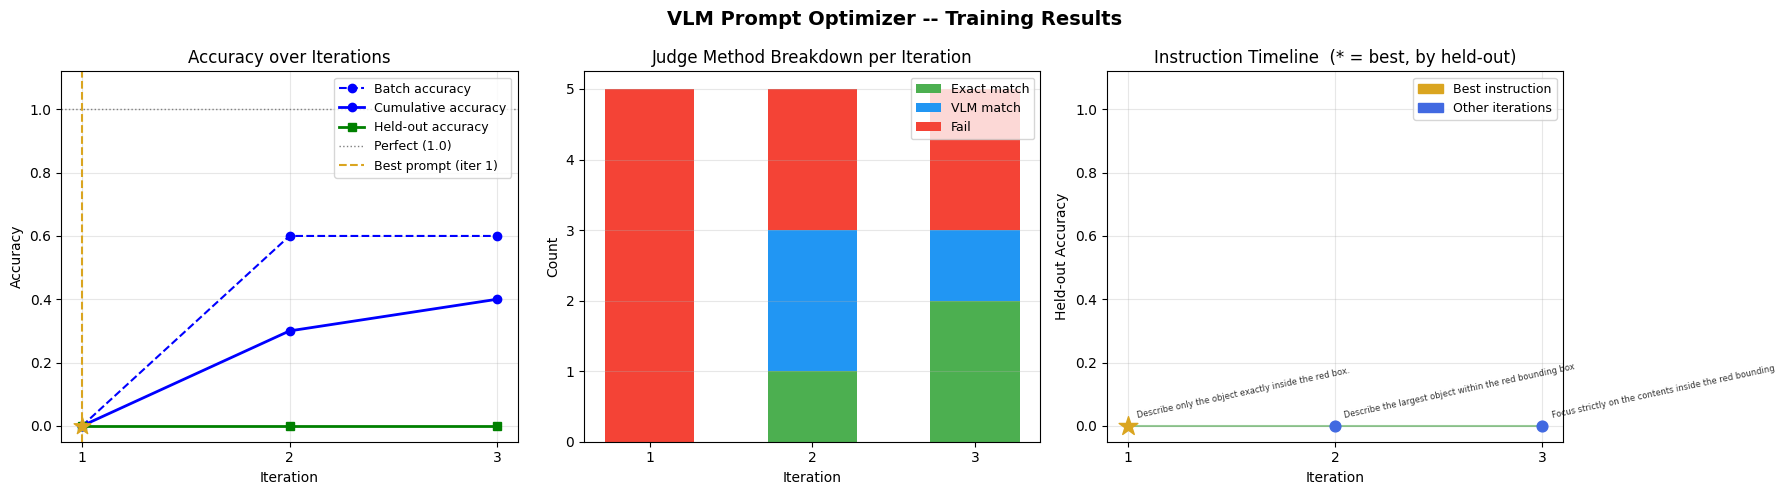

In [30]:
if not prompt_history:
    print('No history yet -- run the optimization loop first.')
else:
    iters      = [r['iteration']                                 for r in prompt_history]
    batch_accs = [r['batch_accuracy']                            for r in prompt_history]
    cumul_accs = [r['cumulative_accuracy']                       for r in prompt_history]
    held_accs  = [r.get('held_out_accuracy', float('nan'))       for r in prompt_history]
    best_iter  = next((r['iteration'] for r in prompt_history
                       if r['instruction'] == best_instruction), None)

    # Per-iteration judge method breakdown
    exact_counts, vlm_counts, fail_counts = [], [], []
    for it in iters:
        vs = get_iteration_verdicts(all_verdicts, it)
        exact_counts.append(sum(1 for v in vs if v['match'] and v['method'] == 'exact'))
        vlm_counts.append(  sum(1 for v in vs if v['match'] and v['method'] == 'vlm'))
        fail_counts.append( sum(1 for v in vs if not v['match']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('VLM Prompt Optimizer -- Training Results', fontsize=14, fontweight='bold')

    # -- Panel 1: Accuracy curves ---------------------------------------------
    ax = axes[0]
    ax.plot(iters, batch_accs, 'b--o', label='Batch accuracy',      linewidth=1.5, markersize=6)
    ax.plot(iters, cumul_accs, 'b-o',  label='Cumulative accuracy', linewidth=2,   markersize=6)
    ax.plot(iters, held_accs,  'g-s',  label='Held-out accuracy',   linewidth=2,   markersize=6)
    ax.axhline(1.0, color='grey', linestyle=':', linewidth=1, label='Perfect (1.0)')
    if best_iter is not None:
        ax.axvline(best_iter, color='goldenrod', linestyle='--', linewidth=1.5,
                   label=f'Best prompt (iter {best_iter})')
        ax.scatter([best_iter], [held_accs[best_iter - 1]], s=160, color='goldenrod',
                   zorder=6, marker='*', label='_nolegend_')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy over Iterations')
    ax.set_xticks(iters)
    ax.set_ylim(-0.05, 1.12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # -- Panel 2: Judge method stacked bar ------------------------------------
    ax = axes[1]
    x  = np.arange(len(iters))
    w  = 0.55
    ax.bar(x, exact_counts, w, label='Exact match', color='#4caf50')
    ax.bar(x, vlm_counts,   w, label='VLM match',   color='#2196f3',
           bottom=exact_counts)
    ax.bar(x, fail_counts,  w, label='Fail',         color='#f44336',
           bottom=[e + v for e, v in zip(exact_counts, vlm_counts)])
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Count')
    ax.set_title('Judge Method Breakdown per Iteration')
    ax.set_xticks(x)
    ax.set_xticklabels(iters)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # -- Panel 3: Prompt timeline ---------------------------------------------
    ax = axes[2]
    ax.plot(iters, held_accs, 'g-', linewidth=1.5, alpha=0.4)
    for rec, acc in zip(prompt_history, held_accs):
        it      = rec['iteration']
        is_best = rec['instruction'] == best_instruction
        marker  = '*'         if is_best else 'o'
        color   = 'goldenrod' if is_best else 'royalblue'
        size    = 200         if is_best else 60
        ax.scatter([it], [acc], s=size, color=color, zorder=5, marker=marker)
        label = rec['instruction'].replace('\n', ' ')[:55]
        ax.annotate(label, (it, acc), textcoords='offset points',
                    xytext=(6, 4), fontsize=6, alpha=0.8,
                    rotation=12, ha='left', va='bottom')
    best_patch  = mpatches.Patch(color='goldenrod', label='Best instruction')
    other_patch = mpatches.Patch(color='royalblue', label='Other iterations')
    ax.legend(handles=[best_patch, other_patch], fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Held-out Accuracy')
    ax.set_title('Instruction Timeline  (* = best, by held-out)')
    ax.set_xticks(iters)
    ax.set_ylim(-0.05, 1.12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


### 4.3 Best prompt

In [31]:
if not prompt_history:
    print('No history yet -- run the optimization loop first.')
else:
    print(f'Best instruction  (held-out accuracy: {best_held_out_accuracy:.1%})')
    print('=' * 68)
    print(best_instruction)
    print('=' * 68)
    print(f'\nFull best prompt (instruction + fixed schema):')
    print('-' * 68)
    print(best_prompt)
    print('-' * 68)


Best instruction  (held-out accuracy: 0.0%)
Describe only the object exactly inside the red box.

Full best prompt (instruction + fixed schema):
--------------------------------------------------------------------
Describe only the object exactly inside the red box.

Return exactly one valid JSON object and nothing else.

Schema:
{
  "colour": "<short color description>",
  "object": "<specific object name>",
  "view_independent_descriptors": "<view-independent descriptors>"
}

Rules:
- colour: only the boxed object's visible color(s)
- object: name the specific object
- view_independent_descriptors: only angle-independent descriptors (shape, texture, relations like on/under/held-by)
- Do not output markdown. Output JSON only.
--------------------------------------------------------------------
